# Business Analytics - Assignment 2  

**Assignment Points**: 100    
**Due Date**: Friday of Week 10 (16 May 2025) at 11:55pm   




Name: Ngoc Bao Han Tran <br>
Student Number: 48393479

---

## Use of Resources and Technologies Including Generative Artificial Interlligence


For this assessment, students are not permitted to use generative artificial intelligence tools (GAITs), such as ChatGPT, with the exception of the following limited purposes:

- Generating preliminary ideas for writing or programming
- Editing or improving writing, including grammar and sentence structure


Students must not use GAITs to:

- Support analytical decisions or evaluate outcomes
- Interpret or analyse data outputs, e.g., figures or tables 
- Generate marketing strategies or targeted recommendations

Use of GAITs beyond the permitted scope will be considered a breach of academic integrity and may be reported as plagiarism. If students use GAITs for approved tasks, the output must be edited and rewritten to show their own work.


---

## Assignment Description

You are employed by a large national gym chain to perform customer segmentation analysis. You are provided with a dataset of 2,000 gym members, collected through their membership details. The dataset includes variables such as age, gender, annual income, etc. 

Your task is to analyse the data in Python using relevant techniques covered in lectures and identify distinct customer segments within the dataset. 

You will then compile your results into tables and charts and writeup a report of up to **1,000 words** (excluding tables and figures). Ensure your report is informative, intuitive, and easily understandable for management, who may not have a technical background.

---

## Word Count

- Include the total word count at the beginning of your report.  
- The word count applies to the main body of the report and excludes tables and figures.

Deductions for non-compliance:
- 5 marks deducted if the word count is missing (and iLearn's default word count will apply)  
- 5 marks deducted if the report exceeds the word limit by 50–100 words  
- 10 marks deducted if the report exceeds the word limit by more than 100 words

---


## Report Appearance (15 Marks)

Ensure that all tables and charts in your report are clearly formatted, informative, and easy to interpret. The following guidelines should be followed:

1. Titles for tables and figures are clear and descriptive, e.g. Table 1: Summary Statistics
2. No raw Python output is allowed; all tables are cleanly formatted  
3. Values in tables are rounded to three decimal places  
4. All charts have properly labelled axes  
5. All charts and tables are discussed and referenced in the text  (do not include irrelevant content)
6. Font, layout, and formatting are professional, consistent, and easy to read  
7. The overall report has a clean, professional look and feel  


---

## Tasks (85 Marks)

Your report should address the questions listed below under the following headings:

1. **Introduction** (5 marks)
    - Describe the problem, explain what you aim to achieve by solving it, outline the approach you will take to address it, etc.
2. **Exploratory Data Analysis** (20 marks)
    - Perform basic exploratory data analysis, present and comment on key summary statistics, etc.
    - Provide tables and charts (e.g. histograms, pie and bar charts) where appropriate.
3. **Customer Segmentation** (35 marks)
    - Standardise the two numeric variables before performing clustering.  
    - Determine the optimal number of customer segments using the Elbow Method and three well-chosen Silhouette Plots.  
    - Once the optimal number of clusters is identified, apply both K-means++ and Agglomerative Clustering using all variables.  
      - Do not apply any dimensionality reduction. Zero marks will be awarded if this instruction is not followed.  
    - For each clustering technique, provide a summary table showing:  
      - Interpretable cluster centres.  
      - The number of customers in each cluster.
4. **Segment Interpretation and Naming** (10 marks)
    - Using the cluster tables from Question 3, interpret each group by analysing customer attributes. Use as many attributes as possible to build a clear profile of each cluster. Do this for both clustering techniques. Based on these profiles, assign meaningful and intuitive names to each segment.
     - Compare the customer segments identified by the two techniques. Do any clusters overlap?
5. **Marketing Recommendations Based on Customer Segments Identified via K-means++** (10 marks)
    - Provide at least three targeted marketing recommendations for each segment. Ensure your recommendations are:
        - Specific, practical, and actionable.
        - Aligned with each segment’s profile and potential needs.
6. **Conclusion** (5 marks)
    - A summary of what you have done in the report. 
    
---
---


## Assignment Submission

You must submit **two files**:

1. **PDF Report**  
   Submit a PDF document containing your final report intended for company management. This report should be clear, well-structured, and include all relevant tables and charts produced during your analysis. It is recommended that you draft your report in Word and convert it to PDF before submission. *(This report will be formally marked.)*

2. **Jupyter Notebook**  
   Submit your Jupyter Notebook containing the Python code used in your analysis. Your code should be clean, well-commented, and capable of reproducing all outputs (tables and figures) shown in your report. *(This notebook will be reviewed to verify the analysis presented in your report.)*


# Preparing Data

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
import warnings
from sklearn.metrics import silhouette_samples, silhouette_score
from sklearn.cluster import KMeans, AgglomerativeClustering
import numpy as np
# Suppress all UserWarnings
warnings.filterwarnings("ignore")

pd.set_option('display.float_format', '{:.2f}'.format)

set2_c = plt.get_cmap("Set2").colors

# 1. Import
print('1. Import')
customer_data = pd.read_csv('data/data.csv')
print(customer_data.info())

# Drop fully empty rows from the legend
lg= pd.read_csv('data/data legend.csv')
lg.dropna(how='all', inplace=True)

# Optional: Reset display settings to show full text and all columns
pd.set_option('display.max_colwidth', None)
pd.set_option('display.max_columns', None)


1. Import
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   Gender           2000 non-null   int64
 1   Marital Status   2000 non-null   int64
 2   Age              2000 non-null   int64
 3   Education        2000 non-null   int64
 4   Income           2000 non-null   int64
 5   Occupation       2000 non-null   int64
 6   Settlement Size  2000 non-null   int64
dtypes: int64(7)
memory usage: 109.5 KB
None


In [8]:
# Check the structure and data types of the dataset
customer_data.head()

,Gender,Marital Status,Age,Education,Income,Occupation,Settlement Size
0,1,1,39,2,130568,1,2
1,0,0,29,1,80315,0,0
2,1,0,35,0,107067,0,0
3,0,1,56,2,214000,1,0
4,1,1,45,2,158138,1,2


In [9]:
# Check the data legend
lg

,Variable,Range,Description
1,Gender,"{0,1}",Biological sex (gender) of a customer. In this dataset there are only 2 different options.
2,NaN,0,male
3,NaN,1,female
5,Marital Status,"{0,1}",Marital status of a customer.
6,NaN,0,single
7,NaN,1,non-single (divorced / separated / married / widowed)
9,Age,NaN,"The age of the customer in years, calculated as current year minus the year of birth of the customer at the time of creation of the dataset"
11,Education,"{0,1,2,3}",Level of education of the customer
12,NaN,0,other / unknown
13,NaN,1,high school


In [10]:
# Check and display missing values per column (sorted, non-zero only) in customer data
missing_counts = customer_data.isnull().sum()
missing_counts = missing_counts[missing_counts > 0].sort_values(ascending=False)

print(" Missing values per column:")
print(missing_counts)


 Missing values per column:
Series([], dtype: int64)


In [11]:
# Define columns 
columns_to_check = [
    'Gender',
    'Marital Status',
    'Age',
    'Education',
    'Income',
    'Occupation',
    'Settlement Size'
]
# Loop through each column and display:
# - The number of unique values
# - The actual unique values (helps identify typos, formatting issues, or outliers)
for col in columns_to_check:
    print(f"\nUnique values in '{col}' ({customer_data[col].nunique()} total):")
    print(customer_data[col].unique())



Unique values in 'Gender' (2 total):
[1 0]

Unique values in 'Marital Status' (2 total):
[1 0]

Unique values in 'Age' (51 total):
[39 29 35 56 45 40 49 53 54 31 41 32 26 44 50 28 48 33 36 37 43 34 42 24
 52 59 38 55 51 47 22 58 46 30 61 27 62 23 60 57 74 63 66 20 64 65 25 70
 76 21 71]

Unique values in 'Education' (4 total):
[2 1 0 3]

Unique values in 'Income' (1988 total):
[130568  80315 107067 ... 144512  87071 104537]

Unique values in 'Occupation' (3 total):
[1 0 2]

Unique values in 'Settlement Size' (3 total):
[2 0 1]


In [12]:
# Mapping numerical codes to gender labels
gender_labels = {0: 'Male', 1: 'Female'}

# Mapping numerical codes to marital status
marital_status_labels = {0: 'Single', 1: 'Non-single'}

# Mapping numerical codes to levels of education
education_labels = {
    0: 'Other/Unknown',
    1: 'High school',
    2: 'University',
    3: 'Graduate school'
}

# Mapping numerical codes to occupation types
occupation_labels = {
    0: 'Unemployed/Unskilled',
    1: 'Skilled Employee/Official',
    2: 'Management/Self-employed'
}

# Mapping numerical codes to type of settlement (city size)
settlement_labels = {
    0: 'Small city',
    1: 'Mid-sized city',
    2: 'Big city'
}


In [13]:
customer_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   Gender           2000 non-null   int64
 1   Marital Status   2000 non-null   int64
 2   Age              2000 non-null   int64
 3   Education        2000 non-null   int64
 4   Income           2000 non-null   int64
 5   Occupation       2000 non-null   int64
 6   Settlement Size  2000 non-null   int64
dtypes: int64(7)
memory usage: 109.5 KB


# Exploratory Data Analysis

In [15]:
# Set visual style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
palette = sns.color_palette("husl", 8)


In [16]:
# Enhanced version of describe function with both count and percentage for categorical variables

def describe(df):
    # Numerical summary
    num_stats = df[['Age', 'Income']].describe().T
    num_stats['skewness'] = [df['Age'].skew(), df['Income'].skew()]
    
    # Categorical summary with both count and percentage
    cat_vars = ['Gender', 'Marital Status', 'Education', 'Occupation', 'Settlement Size']
    cat_stats = []
    for var in cat_vars:
        counts = df[var].value_counts().sort_index()
        percentages = df[var].value_counts(normalize=True).sort_index().mul(100).round(2)
        cat_df = pd.DataFrame({
            'Variable': var,
            'Category': counts.index,
            'Count': counts.values,
            'Percentage (%)': percentages.values
        })
        cat_stats.append(cat_df)
    
    return num_stats.round(3), pd.concat(cat_stats, ignore_index=True)
    
num_summary, cat_summary = describe(customer_data)

print("Table 2.1: Numerical Variables Summary:")
display(num_summary)
print("\n Table 2.2: Categorical Variables Summary:")
display(cat_summary)


Table 2.1: Numerical Variables Summary:


,count,mean,std,min,25%,50%,75%,max,skewness
Age,2000.00,40.82,9.46,20.00,33.00,40.00,48.00,76.00,0.34
Income,2000.00,137516.20,46184.30,35832.00,101262.75,133004.00,171232.50,309364.00,0.34



 Table 2.2: Categorical Variables Summary:


,Variable,Category,Count,Percentage (%)
0,Gender,0,791,39.55
1,Gender,1,1209,60.45
2,Marital Status,0,999,49.95
3,Marital Status,1,1001,50.05
4,Education,0,192,9.60
5,Education,1,877,43.85
6,Education,2,757,37.85
7,Education,3,174,8.70
8,Occupation,0,992,49.60
9,Occupation,1,791,39.55


In [17]:

# Define reusable histogram plotting function with KDE and better formatting
def histogram_plot(data, feature, title, xlabel, filename, color='skyblue', bins=20):
    plt.figure(figsize=(7, 5))
    sns.histplot(data[feature], bins=bins, kde=True, color=color, edgecolor='black')
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel("Frequency")
    plt.tight_layout()
    plt.savefig(f"{filename}")
    plt.close()

# Apply to Age and Income using requested formatting
histogram_plot(customer_data, 'Age', "Figure 2.1: Age Distribution of Gym Members", "Age (years)", "figure1_age_distribution.png", color='skyblue')
histogram_plot(customer_data, 'Income', "Figure 2.2: Income Distribution of Gym Members", "Income (AUD)", "figure2_income_distribution.png", color='salmon')


In [18]:
fig, axs = plt.subplots(3, 2, figsize=(12, 12))
fig.suptitle("Figure 2.3: The Distribution of Attributes", fontsize=16)

# Flatten axes for easy iteration
axs = axs.flatten()

# Data setup
categories = {
    'Gender': 'Gender',
    'Marital Status': 'Marital Status',
    'Education': 'Education',
    'Occupation': 'Occupation',
    'Settlement Size': 'Settlement Size'
}
colors = plt.cm.Pastel1.colors

# Plot each pie chart
for i, (title, column) in enumerate(categories.items()):
    counts = customer_data[column].value_counts()
    sizes = counts.values
    labels = counts.index

    wedges, texts, autotexts = axs[i].pie(
        sizes,
        autopct='%1.1f%%',
        startangle=90,
        counterclock=False,
        colors=colors[:len(sizes)],
        wedgeprops=dict(edgecolor='white'),
        textprops={'fontsize': 9}
    )
    axs[i].set_title(f"{title} Distribution", fontsize=12)
    axs[i].legend(wedges, labels, title=title, loc="center left", bbox_to_anchor=(1, 0.5), fontsize=9)

# Hide the last empty subplot (6th) if unused
if len(categories) < len(axs):
    axs[-1].axis('off')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.savefig("figure3_distribution_of_attributes_grid.png")
plt.close()


In [19]:

# Define pastel colors for each occupation category
pastel_palette = {
    0: "#FBB4AE",  # Unemployed/Unskilled
    1: "#B3CDE3",  # Skilled Employee/Official
    2: "#CCEBC5"   # Management/Self-employed
}

# Create the pairplot
sns.set(style="ticks")
g = sns.pairplot(
    data=customer_data[['Gender', 'Marital Status', 'Age', 'Education', 'Income', 'Occupation', 'Settlement Size']],
    hue='Occupation',
    palette=pastel_palette,
    diag_kind='kde',
    plot_kws={'alpha': 0.6, 's': 30},
    corner=False
)

# Set a main title
g.fig.suptitle('Figure 2.4: Customer Demographics by Occupation', fontsize=14, y=1.05)

# Update legend title and labels
g._legend.set_title("Occupation")
new_labels = ['Unemployed/Unskilled', 'Skilled Employee/Official', 'Management/Self-employed']
for text, label in zip(g._legend.texts, new_labels):
    text.set_text(label)

# Move the legend outside the plot
g._legend.set_bbox_to_anchor((1.15, 0.5))  # Right side, vertically centered
g._legend.set_frame_on(True)

# Fix layout to prevent cutting off the title
plt.subplots_adjust(top=1.01)  # Adjust top margin to make room for title

# Save and close
plt.savefig("figure3_distribution_of_attributes_grid.png", bbox_inches='tight')
plt.close()


# Customer Segmentation

## Standardize variables Age and Income using StandardScaler


In [22]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
customer_data[['Age', 'Income']] = scaler.fit_transform(customer_data[['Age', 'Income']])
customer_data.head()

,Gender,Marital Status,Age,Education,Income,Occupation,Settlement Size
0,1,1,-0.19,2,-0.15,1,2
1,0,0,-1.25,1,-1.24,0,0
2,1,0,-0.62,0,-0.66,0,0
3,0,1,1.61,2,1.66,1,0
4,1,1,0.44,2,0.45,1,2


## Choose the optimal number of customer segments/clusters using the Elbow Method and 3 appropriately chosen Silhouette Plots

In [24]:

# Using the Elbow Method to find the optimal number of clusters for K-means++
inertias = []
k_range = range(1, 11)
for i in k_range:
    kmeans = KMeans(n_clusters = i, 
                init = 'k-means++', 
                n_init = 10, 
                max_iter = 300, 
                random_state = 0)
    kmeans.fit(customer_data)
    inertias.append(kmeans.inertia_)

# Plotting the Elbow Method
plt.figure(figsize=(8, 5))
plt.plot(k_range, inertias, marker='o')
plt.title('Figure 3.1: Elbow Method for Optimal Number of Clusters')
plt.xlabel('Number of Clusters')
plt.ylabel('Cluster inertia (within-cluster SSE)')
plt.grid(True)
# Save and close
plt.savefig("figure4_elbow method.png", bbox_inches='tight')
plt.close()


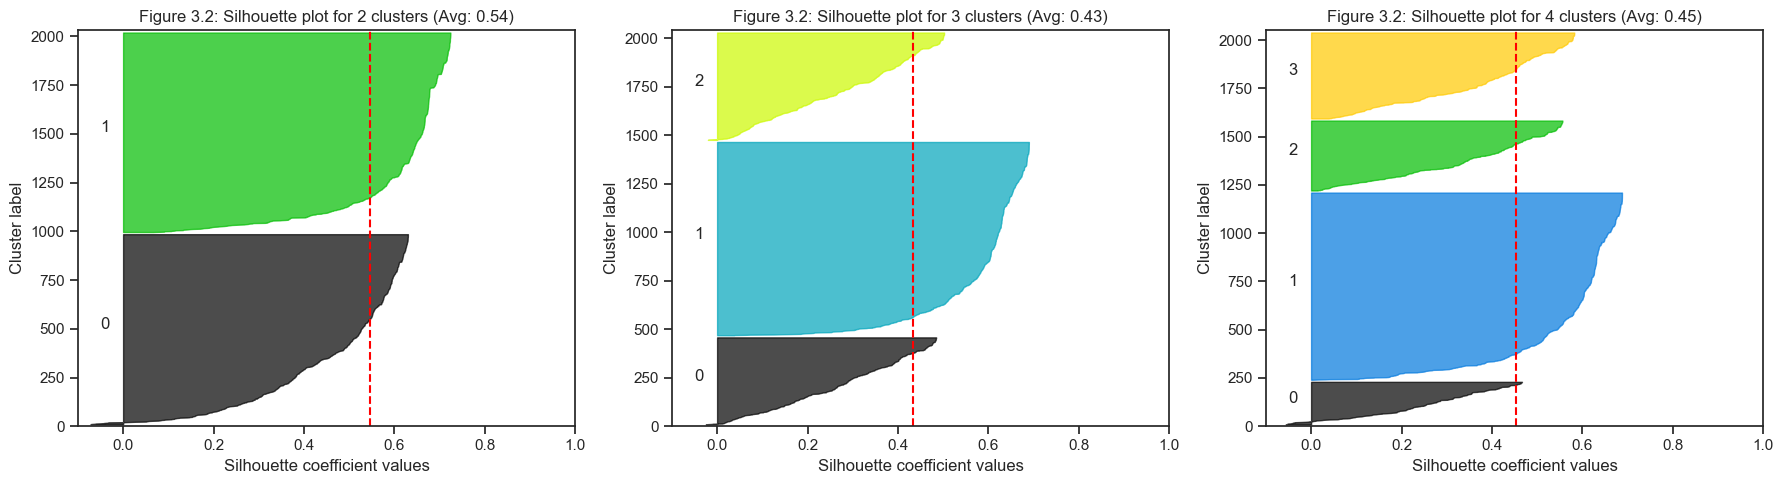

In [25]:
# Silhouette Plots

# Define the range of clusters for which to generate silhouette plots
# Based on the elbow plot, let's assume clusters between 2 and 4 as a starting point
cluster_options = [2, 3, 4]

# Set up the figure for plotting
fig, axes = plt.subplots(1, len(cluster_options), figsize=(18, 5))

for idx, n_clusters in enumerate(cluster_options):
    # Initialize the KMeans model with k-means++
    kmeans = KMeans(n_clusters=n_clusters, init='k-means++', 
            n_init=10, 
            max_iter=300,
            tol=1e-04,
            random_state=0)
    cluster_labels = kmeans.fit_predict(customer_data)
    
    # Calculate the silhouette score and the silhouette values
    silhouette_avg = silhouette_score(customer_data, cluster_labels)
    sample_silhouette_values = silhouette_samples(customer_data, cluster_labels)

    # Plot silhouette for each cluster
    y_lower = 10
    axes[idx].set_xlim([-0.1, 1])
    axes[idx].set_ylim([0, len(customer_data) + (n_clusters + 1) * 10])
    
    for i in range(n_clusters):
        # Aggregate the silhouette scores for samples belonging to cluster i
        ith_cluster_silhouette_values = sample_silhouette_values[cluster_labels == i]
        ith_cluster_silhouette_values.sort()
        
        size_cluster_i = ith_cluster_silhouette_values.shape[0]
        y_upper = y_lower + size_cluster_i

        color = plt.cm.nipy_spectral(float(i) / n_clusters)
        axes[idx].fill_betweenx(np.arange(y_lower, y_upper),
                                0, ith_cluster_silhouette_values,
                                facecolor=color, edgecolor=color, alpha=0.7)
        axes[idx].text(-0.05, y_lower + 0.5 * size_cluster_i, str(i))
        
        y_lower = y_upper + 10  # 10 for the 0 samples separation between clusters

    axes[idx].set_title(f"Figure 3.2: Silhouette plot for {n_clusters} clusters (Avg: {silhouette_avg:.2f})")
    axes[idx].set_xlabel("Silhouette coefficient values")
    axes[idx].set_ylabel("Cluster label")
    axes[idx].axvline(x=silhouette_avg, color="red", linestyle="--")

plt.tight_layout()
plt.savefig('Figure5_silhouette_plot.png', dpi=300)


# Once the optimal number of clusters is identified, apply both K-means++ and Agglomerative Clustering using all variables. 

## K-means++

In [28]:

# Define features used in clustering
features = ['Gender', 'Marital Status', 'Age', 'Education', 'Income', 'Occupation', 'Settlement Size']

# Fit KMeans and assign cluster labels
kmeans = KMeans(n_clusters=2, init='k-means++')
customer_data['KMeans_Cluster'] = kmeans.fit_predict(customer_data[features])

# Create cluster center summary using mean for numerical, mode for categorical
kmeans_centers = customer_data.groupby('KMeans_Cluster').agg({
    'Gender': 'mean',  # proportion female
    'Marital Status': 'mean',  # proportion non-single
    'Age': 'mean',
    'Education': lambda x: x.mode().iloc[0],
    'Income': 'mean',
    'Occupation': lambda x: x.mode().iloc[0],
    'Settlement Size': lambda x: x.mode().iloc[0]
})

# Add cluster sizes
kmeans_centers['Count'] = customer_data['KMeans_Cluster'].value_counts().sort_index().values

# Rename index and transpose for presentation
kmeans_centers.index = [f"KMeans Cluster {i}" for i in kmeans_centers.index]
kmeans_centers = kmeans_centers.T
kmeans_centers.columns.name = None

# Display the summary table
kmeans_centers


,KMeans Cluster 0,KMeans Cluster 1
Gender,0.86,0.37
Marital Status,0.99,0.03
Age,0.78,-0.74
Education,2.00,1.00
Income,0.78,-0.74
Occupation,1.00,0.00
Settlement Size,2.00,0.00
Count,976.00,1024.00


In [29]:
# Step 1: Define mapping function for categorical fields
def map_nearest_label(value, mapping_dict):
    return mapping_dict.get(round(value), 'Unknown')

# Step 2: Copy original table and transpose back for mapping
interpreted_kmeans = kmeans_centers.copy().T

# Step 3: Inverse transform Age and Income using fitted scaler
interpreted_kmeans[['Age', 'Income']] = scaler.inverse_transform(interpreted_kmeans[['Age', 'Income']])
interpreted_kmeans[['Age', 'Income']] = interpreted_kmeans[['Age', 'Income']].round(2)

# Step 4: Apply label mappings for categorical variables
interpreted_kmeans['Gender'] = interpreted_kmeans['Gender'].apply(lambda x: map_nearest_label(x, gender_labels))
interpreted_kmeans['Marital Status'] = interpreted_kmeans['Marital Status'].apply(lambda x: map_nearest_label(x, marital_status_labels))
interpreted_kmeans['Education'] = interpreted_kmeans['Education'].apply(lambda x: map_nearest_label(x, education_labels))
interpreted_kmeans['Occupation'] = interpreted_kmeans['Occupation'].apply(lambda x: map_nearest_label(x, occupation_labels))
interpreted_kmeans['Settlement Size'] = interpreted_kmeans['Settlement Size'].apply(lambda x: map_nearest_label(x, settlement_labels))

# Step 5: Transpose back for presentation
interpreted_kmeans = interpreted_kmeans.T
interpreted_kmeans.columns.name = None

# Step 6: Display the interpreted cluster summary
interpreted_kmeans


,KMeans Cluster 0,KMeans Cluster 1
Gender,Female,Male
Marital Status,Non-single,Single
Age,48.18,33.81
Education,University,High school
Income,173460.69,103256.60
Occupation,Skilled Employee/Official,Unemployed/Unskilled
Settlement Size,Big city,Small city
Count,976.00,1024.00


# Agglomerative

In [31]:
agglo = AgglomerativeClustering(n_clusters=2, metric='euclidean', linkage='complete')

customer_data['Agglo_Cluster'] = agglo.fit_predict(customer_data[features])

# Step 1: Numerical means (Age and Income only)
agglo_centroids = customer_data.groupby('Agglo_Cluster')[['Age', 'Income']].mean()



# Step 3: Add proportion-based averages (Gender and Marital Status)
agglo_centroids['Gender'] = customer_data.groupby('Agglo_Cluster')['Gender'].mean().round(2)
agglo_centroids['Marital Status'] = customer_data.groupby('Agglo_Cluster')['Marital Status'].mean().round(2)

# Step 4: Add mode-based categorical values
agglo_centroids['Education'] = customer_data.groupby('Agglo_Cluster')['Education'].agg(lambda x: x.mode().iloc[0])
# Step 2: Inverse transform standardized Age and Income if needed
agglo_centroids[['Age', 'Income']] = scaler.inverse_transform(agglo_centroids[['Age', 'Income']])
agglo_centroids[['Age', 'Income']] = agglo_centroids[['Age', 'Income']].round(2)
agglo_centroids['Occupation'] = customer_data.groupby('Agglo_Cluster')['Occupation'].agg(lambda x: x.mode().iloc[0])
agglo_centroids['Settlement Size'] = customer_data.groupby('Agglo_Cluster')['Settlement Size'].agg(lambda x: x.mode().iloc[0])

agglo_centroids['Count'] = customer_data['Agglo_Cluster'].value_counts().sort_index().values
# Step 5: Rename index and transpose for presentation
agglo_centroids.index = [f'Agglomerative Cluster {i}' for i in agglo_centroids.index]
agglo_centroids.columns.name = None

agglo_centroids.T

,Agglomerative Cluster 0,Agglomerative Cluster 1
Age,47.08,32.13
Income,168085.08,95041.15
Gender,0.77,0.37
Marital Status,0.86,0.01
Education,2.00,1.00
Occupation,1.00,0.00
Settlement Size,2.00,0.00
Count,1163.00,837.00


In [32]:
# Step 5: Apply label mapping to categorical fields
def map_label(value, mapping):
    return mapping.get(round(value), 'Unknown')

agglo_centroids['Gender'] = agglo_centroids['Gender'].apply(lambda x: map_label(x, gender_labels))
agglo_centroids['Marital Status'] = agglo_centroids['Marital Status'].apply(lambda x: map_label(x, marital_status_labels))
agglo_centroids['Education'] = agglo_centroids['Education'].apply(lambda x: map_label(x, education_labels))
agglo_centroids['Occupation'] = agglo_centroids['Occupation'].apply(lambda x: map_label(x, occupation_labels))
agglo_centroids['Settlement Size'] = agglo_centroids['Settlement Size'].apply(lambda x: map_label(x, settlement_labels))


agglo_summary = agglo_centroids.T

# Step 7: Display
agglo_summary

,Agglomerative Cluster 0,Agglomerative Cluster 1
Age,47.08,32.13
Income,168085.08,95041.15
Gender,Female,Male
Marital Status,Non-single,Single
Education,University,High school
Occupation,Skilled Employee/Official,Unemployed/Unskilled
Settlement Size,Big city,Small city
Count,1163,837


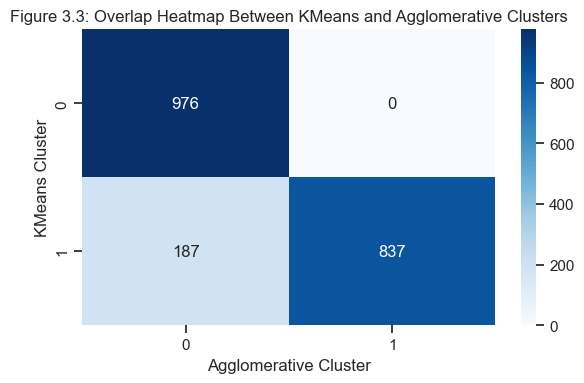

In [33]:

# Create a crosstab (confusion matrix) between KMeans and Agglomerative clustering
overlap_matrix = pd.crosstab(customer_data['KMeans_Cluster'], customer_data['Agglo_Cluster'])

# Plot heatmap
plt.figure(figsize=(6, 4))
sns.heatmap(overlap_matrix, annot=True, fmt='d', cmap='Blues')
plt.title('Figure 3.3: Overlap Heatmap Between KMeans and Agglomerative Clusters')
plt.xlabel('Agglomerative Cluster')
plt.ylabel('KMeans Cluster')
plt.tight_layout()

plt.savefig('Figure6_Cluster_Overlap.png',dpi=300)

